In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("../data/raw/demand.csv")

In [4]:
print("Shape: ", df.shape)
print("Columns: ", df.columns.tolist())

Shape:  (1048575, 5)
Columns:  ['Product_Code', 'Warehouse', 'Product_Category', 'Date', 'Order_Demand']


In [5]:
df.head()

,Product_Code,Warehouse,Product_Category,Date,Order_Demand
0,Product_0993,Whse_J,Category_028,2012/7/27,100
1,Product_0979,Whse_J,Category_028,2012/1/19,500
2,Product_0979,Whse_J,Category_028,2012/2/3,500
3,Product_0979,Whse_J,Category_028,2012/2/9,500
4,Product_0979,Whse_J,Category_028,2012/3/2,500


In [6]:
df["Date"] = pd.to_datetime(df["Date"])

In [7]:
df.dtypes

Product_Code                object
Warehouse                   object
Product_Category            object
Date                datetime64[ns]
Order_Demand                object
dtype: object

In [8]:
df.isnull().sum

<bound method DataFrame.sum of          Product_Code  Warehouse  Product_Category   Date  Order_Demand
0               False      False             False  False         False
1               False      False             False  False         False
2               False      False             False  False         False
3               False      False             False  False         False
4               False      False             False  False         False
...               ...        ...               ...    ...           ...
1048570         False      False             False  False         False
1048571         False      False             False  False         False
1048572         False      False             False  False         False
1048573         False      False             False  False         False
1048574         False      False             False  False         False

[1048575 rows x 5 columns]>

In [9]:
# Granularity and structure analysis

# print("Date Range: ")
# print(df["Date"].min(), "to", df["Date"].max())

# print("\nUnique warehouses: ", df["Warehouse"].nunique())
# print("\nUnique products: ", df["Product_Code"].nunique())
# print("\nUnique product catagories: ", df["Product_Category"].nunique())

# date_diff = df["Date"].sort_values().diff().dropna()
# print("\nMost common difference between consecutive dates: ")
# print(date_diff.value_counts().head())

## Granularity & Structure Analysis

# - The dataset is a time-series demand dataset indexed by Date.
# - Date range spans from 2011-01-08 to 2017-01-09.
# - Number of unique warehouses: 4.
# - Number of unique products: 2160.
# - Number of unique product categories: 33.
# - Multiple records exist for the same date, as indicated by a zero-day difference being the most common.
# - This suggests the data is an event-based demand log across products and warehouses rather than a single continuous daily time series.
# - Order_Demand was originally stored as string values and was converted to numeric format for analysis.

In [12]:
#Daily Aggregation of total demand

df["Order_Demand"] = (df["Order_Demand"]
                      .astype(str)
                      .str.replace(",","",regex = False)
                     )
df["Order_Demand"] = pd.to_numeric(df["Order_Demand"], errors = "coerce")
df["Order_Demand"].dtype

daily_demand = (
    df.groupby("Date", as_index = False)["Order_Demand"]
    .sum()
)

daily_demand.head()

,Date,Order_Demand
0,2011-01-08,2.0
1,2011-05-31,108.0
2,2011-06-24,92000.0
3,2011-09-02,1250.0
4,2011-09-27,28.0


C:\Users\dell\AppData\Local\Temp\ipykernel_16268\1909625452.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["Order_Demand"]


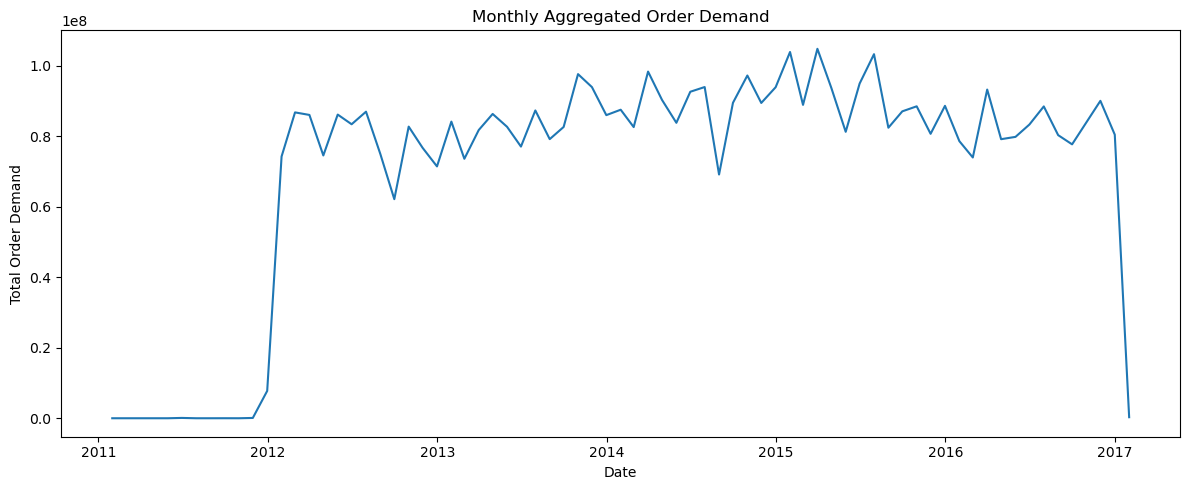

In [19]:
import matplotlib.pyplot as plt

#Monthly aggregation + plot

monthly_demand = (
    df.set_index("Date")
    .resample("M")["Order_Demand"]
    .sum()
    .reset_index()
)

plt.figure(figsize = (12,5))
plt.plot(monthly_demand["Date"], monthly_demand["Order_Demand"])
plt.title("Monthly Aggregated Order Demand")
plt.xlabel("Date")
plt.ylabel("Total Order Demand")
plt.tight_layout()
plt.show()

In [21]:
## Trend & Aggregation Analysis

# - Daily aggregated demand exhibits high variability due to multiple products and warehouses contributing orders on the same date.
# - Monthly aggregation smooths short-term noise and reveals clearer long-term patterns.
# - The multi-year trend indicates non-stationary behavior, with changes in demand levels over time.
# - These observations motivate the use of time-aware models and rolling-window evaluation rather than random train-test splits.

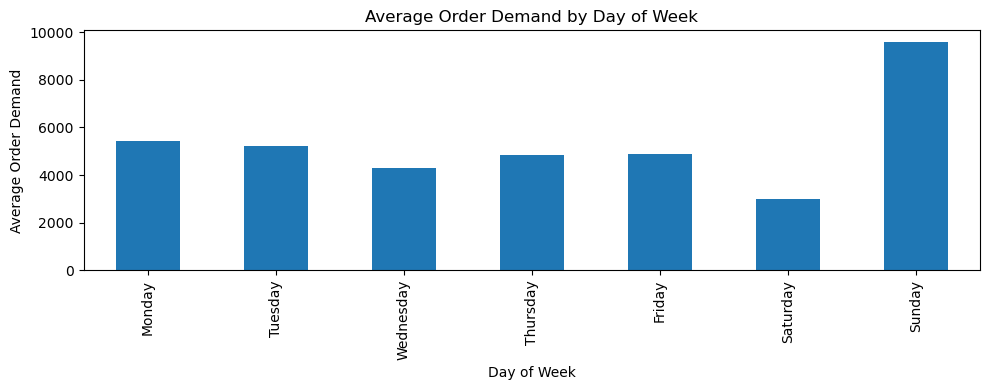

In [24]:
#day of the week seasonality

df["day_of_the_week"] = df["Date"].dt.day_name()

dow_demand = (
    df.groupby("day_of_the_week")["Order_Demand"]
    .mean()
    .reindex(["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
)

plt.figure(figsize = (10,4))
dow_demand.plot(kind = "bar")
plt.title("Average Order Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Order Demand")
plt.tight_layout()
plt.show()

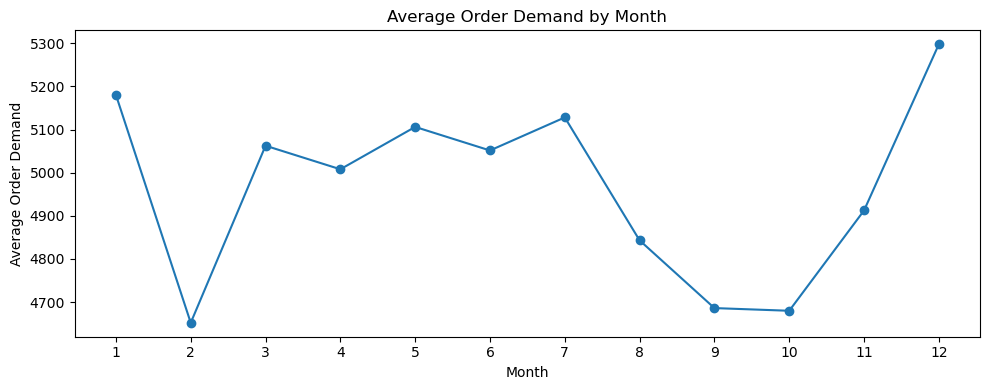

In [26]:
#month of year seasonality

df["month"] = df["Date"].dt.month

moy_demand = (
    df.groupby("month")["Order_Demand"]
    .mean()
)

plt.figure(figsize = (10,4))
plt.plot(moy_demand.index, moy_demand.values, marker="o")
plt.title("Average Order Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Order Demand")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

In [ ]:
## Seasonality Analysis

# - Average demand varies across days of the week, indicating weekly seasonality in ordering behavior.
# - Certain weekdays consistently show higher demand compared to others.
# - Monthly aggregation reveals yearly seasonality, with demand fluctuating across different months.
# - These patterns justify the inclusion of calendar-based features such as day-of-week and month in forecasting models.